In [1]:
!pip install "numpy<2" qdrant-client deepface tf-keras opencv-python-headless

INFO: pip is looking at multiple versions of opencv-python-headless to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.2/377.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.1/133.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.9/319.9 kB 1

In [ ]:
import os  # Import pour la gestion des fichiers et dossiers (OS = Operating System)
import tarfile  # Import pour décompresser les archives .tgz (format compressé Linux)
import cv2  # Import d'OpenCV : la librairie standard pour le traitement d'image (affichage, redimensionnement)
import numpy as np  # Import de NumPy pour gérer les tableaux de nombres (les images sont des matrices de pixels)
import matplotlib.pyplot as plt  # Import pour afficher les graphiques et images dans le notebook
from qdrant_client import QdrantClient  # Import du client pour la Base de Données Vectorielle Qdrant
from qdrant_client.models import Distance, VectorParams, PointStruct  # Import des objets de configuration pour la base vectorielle
from deepface import DeepFace  # Import de la librairie DeepFace qui simplifie l'utilisation des modèles de reconnaissance faciale

2025-12-30 13:05:01.570219: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767099901.812740      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767099901.881254      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


25-12-30 13:05:20 - Directory /root/.deepface has been created
25-12-30 13:05:20 - Directory /root/.deepface/weights has been created


# --- 1. DÉCOMPRESSION DU DATASET ---

In [ ]:
print("📦 Préparation des données...")  # Log utilisateur

# Chemin du fichier dans ton Input Kaggle
source_tar = "/kaggle/input/lfw-funneled.tgz"  # Définition du chemin source de la dataset (Labeled Faces in the Wild)
# Dossier de destination (Espace de travail inscriptible de Kaggle)
dest_dir = "/kaggle/working/lfw_dataset"  # Définition du dossier de travail où on va extraire les fichiers

if not os.path.exists(dest_dir):  # Vérification : si le dossier n'existe pas, on lance l'extraction
    print("⏳ Décompression de l'archive lfw-funneled.tgz (cela peut prendre quelques secondes)...")
    try:  # Bloc de sécurité pour la décompression
        with tarfile.open(source_tar, "r:gz") as tar:  # Ouverture de l'archive en mode lecture compressée gzip
            tar.extractall(path=dest_dir)  # Extraction de tous les fichiers vers le dossier cible
        print("✅ Décompression terminée !")  # Confirmation
    except FileNotFoundError:  # Gestion d'erreur si le fichier Kaggle n'est pas trouvé
        print(f"❌ ERREUR : Le fichier {source_tar} est introuvable. Vérifie le chemin dans 'Add Input'.")
else:  # Si le dossier existe déjà (ex: relance du script)
    print("✅ Dossier déjà décompressé, on continue.")  # On saute l'étape pour gagner du temps

# Le dossier racine des images après décompression
root_images = os.path.join(dest_dir, "lfw_funneled")  # Construction du chemin absolu vers les images décompressées

📦 Préparation des données...
⏳ Décompression de l'archive lfw-funneled.tgz (cela peut prendre quelques secondes)...
✅ Décompression terminée !


# --- 2. INITIALISATION QDRANT ---

In [ ]:
client = QdrantClient(":memory:")  # Initialisation de Qdrant en mode RAM (volatile). Pour la prod, on mettrait une IP serveur.
collection_name = "base_employes"  # Nom de la collection (équivalent d'une table SQL)

client.recreate_collection(  # Création (ou écrasement) de la collection vectorielle
    collection_name=collection_name,
    vectors_config=VectorParams(size=4096, distance=Distance.COSINE),  # Config cruciale : 4096 = taille sortie VGG-Face, Cosine = meilleure métrique pour les visages
)

True

# --- 3. INGESTION (Remplissage de la base) ---

In [ ]:
print("⚙️ Enrôlement des employés dans la base vectorielle...")  # Log de début d'indexation

points = []  # Liste tampon pour stocker les points avant de les envoyer en lot (batch) à Qdrant
global_id = 0  # Identifiant unique numérique requis par Qdrant pour chaque point
limite_employes = 500  # Limite artificielle pour ne pas traiter les 13 000 images du dataset (gain de temps)

# On parcourt les dossiers extraits
# Structure : /lfw_funneled/Nom_Prenom/Nom_Prenom_0001.jpg
for root, dirs, files in os.walk(root_images):  # Boucle récursive sur tous les dossiers
    if global_id >= limite_employes:  # Condition d'arrêt si la limite est atteinte
        break
    
    # On cherche les images jpg
    jpg_files = [f for f in files if f.endswith('.jpg')]  # Filtrage pour ne garder que les fichiers images
    
    if jpg_files:  # Si le dossier contient une image (c'est une personne)
        # On prend la première photo trouvée pour cette personne
        image_name = jpg_files[0]  # On sélectionne la première photo
        image_path = os.path.join(root, image_name)  # Construction du chemin complet de l'image
        
        # Le nom de la personne est le nom du dossier parent
        nom_personne = os.path.basename(root)  # Extraction du nom du dossier (Label)
        
        try:  # Bloc try pour éviter que le script plante si une image est corrompue
            # DeepFace vectorise l'image
            embedding = DeepFace.represent(  # Appel à l'IA pour transformer l'image en nombres
                img_path=image_path, 
                model_name="VGG-Face",  # Choix du modèle (VGG-Face est robuste et précis)
                enforce_detection=False  # Important : si aucun visage n'est détecté clairement, on essaie quand même d'extraire (évite les erreurs)
            )[0]["embedding"]  # On récupère uniquement la liste de nombres (le vecteur)
            
            points.append(PointStruct(  # Création de l'objet "Point" pour Qdrant
                id=global_id,  # L'ID unique
                vector=embedding,  # L'empreinte numérique du visage
                payload={"nom": nom_personne, "path": image_path}  # Les métadonnées (Nom, Chemin) pour l'affichage
            ))
            
            global_id += 1  # Incrémentation du compteur
            if global_id % 50 == 0:  # Log tous les 50 visages traités pour le suivi
                print(f"   ... {global_id} employés traités")
                
        except Exception as e:  # Si une erreur survient sur une image spécifique
            continue # Erreur sur une image, on passe à la suivante sans crasher

# Envoi vers Qdrant
if points:  # Vérification qu'on a bien trouvé des visages
    client.upsert(collection_name=collection_name, points=points)  # Upload en masse (Batch Upsert) vers la base de données
    print(f"✅ Terminé ! {global_id} visages sont stockés dans la base de l'entreprise.")
else:
    print("❌ ERREUR : Aucune image n'a été trouvée. Vérifie les chemins.")

⚙️ Enrôlement des employés dans la base vectorielle...


2025-12-30 13:05:27.475797: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


25-12-30 13:05:28 - 🔗 vgg_face_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/vgg_face_weights.h5 to /root/.deepface/weights/vgg_face_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/vgg_face_weights.h5
To: /root/.deepface/weights/vgg_face_weights.h5
100%|██████████| 580M/580M [00:03<00:00, 191MB/s]


   ... 50 employés traités
   ... 100 employés traités
   ... 150 employés traités
   ... 200 employés traités
   ... 250 employés traités
   ... 300 employés traités
   ... 350 employés traités
   ... 400 employés traités
   ... 450 employés traités
   ... 500 employés traités
✅ Terminé ! 500 visages sont stockés dans la base de l'entreprise.


# --- 4. FONCTION DE RECONNAISSANCE ---

In [ ]:
def reconnaitre_visage(chemin_photo):  # Définition de la fonction de reconnaissance (Inférence)
    """
    Prend le chemin d'une photo, l'analyse et cherche la personne dans la base Qdrant.
    """
    print(f"\n🔎 Analyse de l'image...")
    
    # Petit affichage de l'image (Optionnel)
    try:
        img_show = cv2.imread(chemin_photo)  # Lecture de l'image avec OpenCV
        if img_show is not None:
            img_show = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)  # Conversion BGR (OpenCV) vers RGB (Matplotlib)
            plt.imshow(img_show)  # Préparation de l'affichage
            plt.axis('off')  # Masquage des axes X/Y
            plt.show()  # Affichage réel
    except: pass  # Si l'affichage échoue (pas d'écran), on continue quand même le calcul

    try:
        # 1. Vectorisation
        vec_inconnu = DeepFace.represent(img_path=chemin_photo, model_name="VGG-Face", enforce_detection=True)[0]["embedding"]  # Ici enforce_detection=True car on VEUT être sûr qu'il y a un visage sur la photo d'entrée
        
        # 2. Recherche Qdrant (Avec CORRECTIF pour l'erreur "no attribute search")
        try:  # Bloc de compatibilité pour gérer différentes versions de la librairie Qdrant
            # On essaie la méthode standard
            result = client.search(  # Recherche des vecteurs les plus proches (Nearest Neighbors)
                collection_name="base_employes",  # Dans quelle table chercher
                query_vector=vec_inconnu,  # Le vecteur de la personne inconnue
                limit=1  # On veut seulement le candidat le plus ressemblant (Top-1)
            )
        except AttributeError:  # Si la méthode .search n'existe pas sur cette version du client
            # PLAN B : Si .search() n'existe pas, on utilise .query_points()
            # C'est la méthode bas niveau qui marche toujours
            result = client.query_points(  # Méthode alternative bas niveau
                collection_name="base_employes",
                query=vec_inconnu,
                limit=1
            ).points  # Récupération de la liste des points
        
        # 3. Résultat
        if result:  # Si la base de données a renvoyé un résultat
            trouve = result[0]  # On prend le premier (le plus proche)
            # Attention : selon la méthode utilisée, 'payload' est parfois un objet ou un dict
            # On gère les deux cas
            payload = trouve.payload  # Récupération des infos (Nom, Photo)
            nom = payload['nom'] if isinstance(payload, dict) else payload.nom  # Extraction sécurisée du nom
            
            score = trouve.score  # Récupération du score de similarité (Cosinus)
            seuil_minimum = 0.50  # Définition du seuil de confiance (Threshold). En dessous, on considère que c'est un inconnu.
            
            if score > seuil_minimum:  # Si la ressemblance est forte
                print(f"✅ IDENTIFIÉ : C'est {nom}")
                print(f"📊 Confiance : {score:.4f}")  # Affichage du score
            else:  # Si la ressemblance est trop faible (ex: 0.3)
                print(f"⚠️ VISAGE INCONNU (Ressemble vaguement à {nom}, Score: {score:.4f})")
        else:
            print("❌ Aucune correspondance trouvée.")  # Cas rare : base vide ou erreur
            
    except ValueError:  # Erreur levée par DeepFace si aucun visage n'est détecté
        print("❌ ERREUR : Aucun visage détecté sur cette photo.")
    except Exception as e:  # Erreur générique
        print(f"❌ ERREUR TECHNIQUE : {str(e)}")

# --- 7. TESTS : photo présente ---


--- TEST 1 : Employé Connu ---
(On teste avec la photo de : Penelope_Taylor)

🔎 Analyse de l'image...


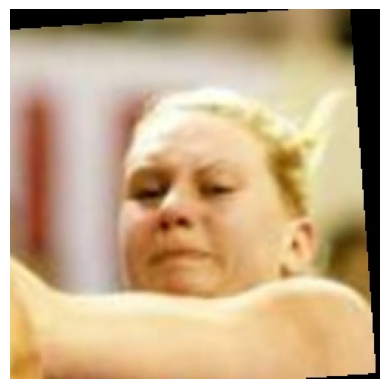

✅ IDENTIFIÉ : C'est Penelope_Taylor
📊 Confiance : 1.0000


In [ ]:
print("\n--- TEST 1 : Employé Connu ---")  # Début du test de validation
# On récupère le chemin d'un employé qu'on a mis dans la base (le dernier ajouté)
if points:
    dernier_employe = points[-1].payload  # On prend le dernier inscrit pour tester
    print(f"(On teste avec la photo de : {dernier_employe['nom']})")
    reconnaitre_visage(dernier_employe['path'])  # Lancement de la reconnaissance sur une image connue

# --- 8. TESTS : photo absente ---


--- TEST 2 : Intrus (BaMrack Obama) ---
⏳ Téléchargement depuis GitHub (Source fiable)...
✅ Photo téléchargée avec succès !

🔎 Analyse de l'image...


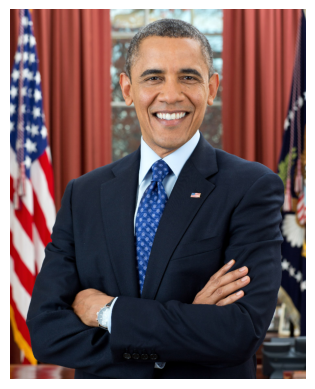

⚠️ VISAGE INCONNU (Ressemble vaguement à Doug_Christie, Score: 0.3147)


In [ ]:
# --- TEST 2 : Intrus (Barack Obama via GitHub) ---
import requests  # Import pour télécharger l'image depuis le web

print("\n--- TEST 2 : Intrus (BaMrack Obama) ---")  # Test avec une personne qui N'EST PAS dans la base

# ON CHANGE LA SOURCE : On utilise GitHub (Raw) qui ne bloque jamais
url_inconnu = "https://raw.githubusercontent.com/ageitgey/face_recognition/master/examples/obama.jpg"  # URL stable d'une photo d'Obama
chemin_intrus = "/kaggle/working/intrus.jpg"  # Chemin local pour sauvegarder l'image

try:
    print(f"⏳ Téléchargement depuis GitHub (Source fiable)...")
    
    # Pas besoin de User-Agent compliqué pour GitHub
    reponse = requests.get(url_inconnu, timeout=10)  # Téléchargement HTTP
    
    if reponse.status_code == 200:  # Si le téléchargement a réussi
        with open(chemin_intrus, 'wb') as f:  # Ouverture du fichier en mode écriture binaire (wb)
            f.write(reponse.content)  # Écriture des données de l'image
        print("✅ Photo téléchargée avec succès !")
        
        # Lancement de la reconnaissance
        reconnaitre_visage(chemin_intrus)  # On teste : ça devrait dire "Visage Inconnu" car Obama n'est pas dans la base
    else:
        print(f"❌ Erreur de téléchargement (Code: {reponse.status_code})")
        
except Exception as e:
    print(f"❌ Erreur technique : {e}")